In [1]:
# Copyright 2023 Nico Curti, Gianluca Carlini, and Riccardo Biondi
# Author: Nico Curti
# e-mail: nico.curti2@unibo.it

In [2]:
import pylab as plt
import SimpleITK as sitk
from skimage.data import horse

from graphomics import SkeletonizeImageFilter
from graphomics import GraphThicknessImageFilter

## Graphomics Semantic Segmentation - 2D

Demo of the `GraphThicknessImageFilter` applied for the semantic segmentation task of 2D inputs.

In this demo we will see how we can use the information extracted by the filter as kick-starter for a semantic segmentation task.
The following example is just a proof-of-concept and the results obtained on the sample image are just a demo.
The proposed pipeline, indeed, is totally agnostic by any information about the semantics.

For this demo we will use the data sample provided by the `skimage` library: in particular we will use the standard binary image of the `horse` layout.
In this case there are no pre-determined semantic areas, but we can easily predict the possibility to split the horse shape considering its limbs, tail, head, and ears.

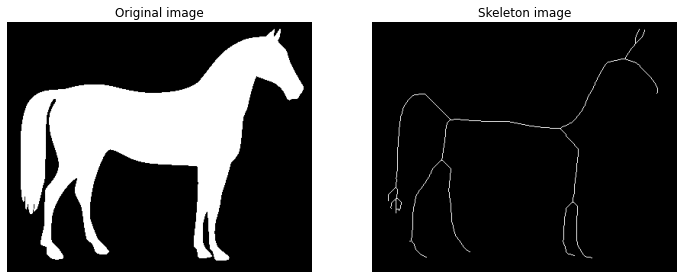

In [3]:
import numpy as np
from skimage.data import horse

# Invert the horse image
image = np.int32(~horse())
# convert it to the SimpleITK fmt
sitk_image = sitk.GetImageFromArray(image)

# define the skeletonizer to use in the following examples
skeletonizer = SkeletonizeImageFilter()

# apply the skleletonization algorithm
skeletonizer.Execute(sitk_image)
# get the resulting image
skeleton = skeletonizer.GetSkeletonImage()

# retro-transform the output to Numpy
np_skeleton = sitk.GetArrayFromImage(skeleton)

# display the results
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6),
                               sharex=True, sharey=True)
_ = ax1.imshow(image, cmap='gray')
_ = ax1.axis('off')
_ = ax1.set_title('Original image')

_ = ax2.imshow(np_skeleton, cmap='gray')
_ = ax2.axis('off')
_ = ax2.set_title('Skeleton image')

Starting from the skeleton image backbone, the purpose of the `Graphomics` is to extract and analyze the underlying graph.
To this purpose we can directly apply the `GraphThicknessImageFilter` and evaluate the extracted network.
In this demo we will particularly focuse on the `edgeMap` produced by the filter.

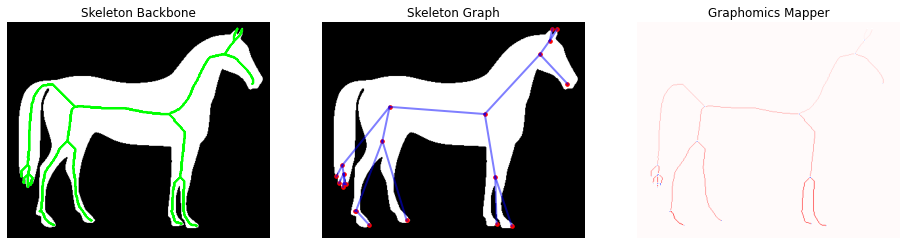

In [4]:
# define the graph extractor to use in the following examples
extractor = GraphThicknessImageFilter(# number of dimension of the image
                                      surface_min_points=8,
                                      # minimum number of points for the node identification
                                      remove_surface=True
                                      # remove the skeleton surfaces
                                      )

# execute the filter
extractor.Execute(skeleton)

# get the computed information about the graph
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edgeMap = extractor.GetEdgeMap()

# transform the edgeMap to Numpy fmt
np_edgeMap = sitk.GetArrayFromImage(edgeMap)

# display the results
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(16, 6),
                                    sharex=True, sharey=True)
_ = ax1.imshow(image, cmap='gray')
_ = ax1.contour(np_skeleton, colors='lime', linewidths=1)
_ = ax1.axis('off')
_ = ax1.set_title('Skeleton Backbone')

_ = ax2.imshow(image, cmap='gray')
_ = ax2.scatter(*zip(*nodes), facecolor='red', marker='.', s=50)
for ex, ey in edges:
    ax2.plot(*zip(*(ex, ey)), color='blue', linewidth=2, alpha=.5)
_ = ax2.axis('off')
_ = ax2.set_title('Skeleton Graph')

_ = ax3.imshow(np_edgeMap, cmap='bwr')
_ = ax3.axis('off')
_ = ax3.set_title('Graphomics Mapper')

For sake of clarity, we report in the following the definition of the `edgeMap` (or `Graphomics Mapper`) computed by the filter:

    The edgeMap image/volume has the same size of the original input, in which
    each edge component is labelled with a different index:
        ° 0    values identify the background.
        ° > 0  values identify the labeled edges found
        ° < -1 values identify the labeled hyper-nodes found

According to this nomenclature we can easily extract a binary mask with only the nodes locations or with only the edge locations.
In this case we are interested in this second option, since the edge curves could be used as starting point for a semantic segmentation of the macro-areas which define the horse shape.
In particular, the `Watershed` algorithm (a standard technique for the semantic segmentation) application relies on the availability of robust markers for the identification of the different ROIs.

In this case we will use the edge mask as initial seed points in a `Watershed` segmentation producing the resulting semantic segmentation of the 2D input image. 

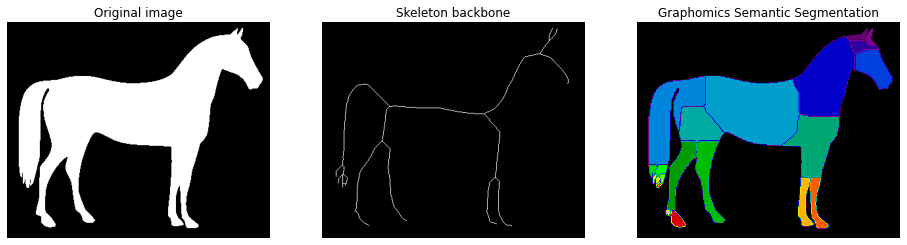

In [5]:
# extract the marker mask filtering the mapper and
# selecting only the positive values, i.e. the edge markers
markers = sitk.Threshold(
  image1=edgeMap,
  lower=0,
  upper=len(edges),
  outsideValue=0
)

# apply the watershed algorithm using the marker image
# for the initialization of the seed points
ws = sitk.MorphologicalWatershedFromMarkers(
  image=edgeMap,
  markerImage=markers,
  markWatershedLine=True,
  fullyConnected=False
)

# mask the resulting watershed segmentation according
# to the original mask
ws = sitk.Mask(
  image=ws,
  maskImage=sitk.GetImageFromArray(image),
  outsideValue=0,
  maskingValue=0,
)
# get the resulting semantic seg as Numpy fmt
semantic_seg = sitk.GetArrayFromImage(ws)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(16, 8))

_ = ax1.imshow(image, cmap='gray')
_ = ax1.axis('off')
_ = ax1.set_title('Original image')

_ = ax2.imshow(np_skeleton, cmap='gray')
_ = ax2.axis('off')
_ = ax2.set_title('Skeleton backbone')

_ = ax3.imshow(semantic_seg, cmap='nipy_spectral')
_ = ax3.axis('off')
_ = ax3.set_title('Graphomics Semantic Segmentation')

We would like to stress that in this case there is no a ground truth about the semantic segmentation, but the possibility to use `Graphomics` output for semantic segmentation tasks extends the potentiality of the proposed technique.

⚠️ **NOTE:** The approach proposed above could be used for the estimation of the graph's weights in the skeleton backbone.
For this reason, the `Graphomics` package provides a ready-to-use implementation of this technique into the list of possible `graph_weights` algorithms (ref. `graphomics/_graph.py` for developer details)

## Graphomics Semantic Segmentation - 3D

Demo of the `GraphThicknessImageFilter` applied for the semantic segmentation task of 3D inputs.

In this demo we will see how we can generalize the previous semantic segmentation task to 3D medical volumes.
The following example is just a proof-of-concept and the results obtained on the sample image are just a demo.
The proposed pipeline, indeed, is totally agnostic by any information about the semantics.

#### Femour anatomical landmarks

For this demo we will use a data sample related to a 3D segmentation of a femour: this data was provided by the collaboration with the IRCCS Rizzoli Hospital of Bologna University.
Further information about the segmentation and data are available in the paper of Biondi et al..
**TODO:** add hyper-link to the paper

In this case there are no pre-determined semantic areas, and the purpose will be to identify the anatomical landmarks of the femour volume with the help of the nodes/edges information obtained by the skeleton graph.

In [115]:
# load the medical image file
from graphomics import LoadImageFileInAnyFormat

# declare the input filename, in this case a Nifti compressed fmt
filename = '../samples/femour_seg.nii.gz'

# load the volume in a sitk.Image
sitk_vol = LoadImageFileInAnyFormat(
    filepath=filename,
    binarize=True
)

# extract the skeleton of the 3D shape

# define the skeletonizer to use in the following examples
skeletonizer = SkeletonizeImageFilter()

# apply the skleletonization algorithm
skeletonizer.Execute(sitk_vol)
# get the resulting image
skeleton = skeletonizer.GetSkeletonImage()

As always the first step is the visualization of the intermediate results.

For the visualization of the 3D mesh we will use the marching_cubes algorithm provided by the scikit-image package.

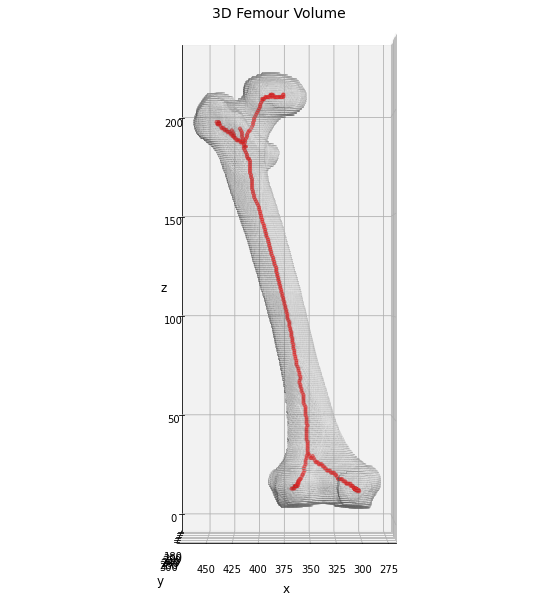

In [116]:
# display 3D mesh
from skimage.measure import marching_cubes

# retro-transform the volume to Numpy fmt for the display
np_vol = sitk.GetArrayViewFromImage(sitk_vol)

# retro-transform the output to Numpy for the display
np_skeleton = sitk.GetArrayFromImage(skeleton)

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(np_vol, 0)

# plot the results in a 3D graph
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.05,
                antialiased=False, 
                linewidth=0.0
               )

# draw the skeleton shape
sz, sy, sx = np.where(np_skeleton)
ax.scatter(sx, sy, sz, color='r', marker='o', s=10, alpha=0.5)

ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)*2))
ax.view_init(elev=0., azim=90)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
_ = ax.set_title('3D Femour Volume', fontsize=14)

In this case we can clearly see that the skeleton of the 3D volume perfectly covers all the anatomical backbone of the bone, providing ramifications only in the top and bottom sections.
The next step involves the extraction of the skeleton graph information as done before in the 2D case.

In [117]:
# define the graph extractor to use in the following examples
extractor = GraphThicknessImageFilter(# number of dimension of the image
                                      surface_min_points=8,
                                      # minimum number of points for the node identification
                                      remove_surface=False
                                      # remove the skeleton surfaces
                                      )

# execute the filter
extractor.Execute(skeleton)

# get the computed information about the graph
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edgeMap = extractor.GetEdgeMap()

# transform the edgeMap to Numpy fmt
np_edgeMap = sitk.GetArrayFromImage(edgeMap)

Display the results for sake of clarity.

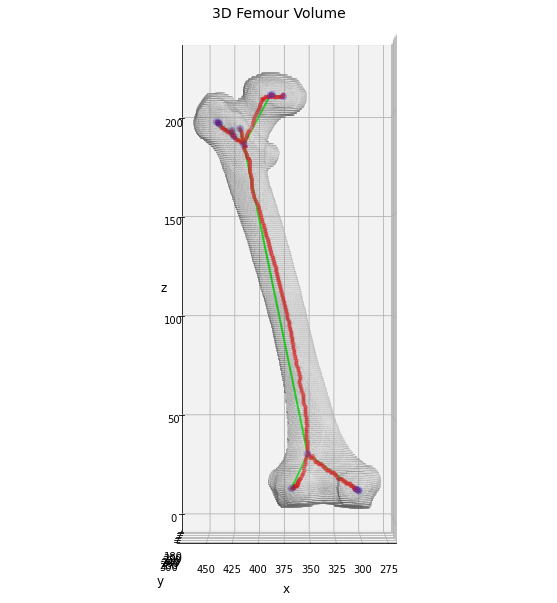

In [118]:
# plot the nodes as blue dots
ax.scatter(*zip(*nodes), color='b', marker='o', s=40, alpha=0.25)
    
# plot the edges as lines between vertices
for ex, ey in edges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)
    
fig

Now we will use the same approach described above for the 2D case, trying to identify the anatomical components of the bone using the Watershed segmentation algorithm initialized using the markers given by the edge components.

In this case could be helpful to compare the results obtained by the edge-marker segmentation with the ones get by considering the graph-nodes as marker points.
In this case we need to partically edit our pipeline, flipping the edgeMap values and/or inverting the initial thresholding for the marker identification.

In [119]:
# extract the marker mask filtering the mapper and
# selecting only the positive values, i.e. the edge markers
markers = sitk.Threshold(
  image1=edgeMap,
  lower=0,
  upper=len(edges),
  outsideValue=0
)

# apply the watershed algorithm using the marker image
# for the initialization of the seed points
ws = sitk.MorphologicalWatershedFromMarkers(
  image=edgeMap,
  markerImage=markers,
  markWatershedLine=True,
  fullyConnected=False
)

# mask the resulting watershed segmentation according
# to the original mask
ws = sitk.Mask(
  image=ws,
  maskImage=sitk_vol,
  outsideValue=0,
  maskingValue=0,
)
# get the resulting semantic seg as Numpy fmt
semantic_seg_edge_markers = sitk.GetArrayFromImage(ws)

In [120]:
# extract the marker mask filtering the mapper and
# selecting only the negative values, i.e. the node markers
markers = sitk.Threshold(
  image1=edgeMap,
  lower=-len(nodes), # note the flip
  upper=0,
  outsideValue=0
)

# apply the watershed algorithm using the marker image
# for the initialization of the seed points
ws = sitk.MorphologicalWatershedFromMarkers(
  image=edgeMap,
  markerImage=-markers,  # note the flip
  markWatershedLine=True,
  fullyConnected=False
)

# mask the resulting watershed segmentation according
# to the original mask
ws = sitk.Mask(
  image=ws,
  maskImage=sitk_vol,
  outsideValue=0,
  maskingValue=0,
)
# get the resulting semantic seg as Numpy fmt
semantic_seg_node_markers = sitk.GetArrayFromImage(ws)

Now we can display the results in a 3D colored plot, comparing the segmentation obtained by the edge-markers with the one given by the node-markers initialization.
In both the cases, the final aim is to obtain an easy-and-fast evaluation of the anatomical regions of the bone, or, at least, of the most significant regions for bio-engeneering applications as showed in Biondi et al.

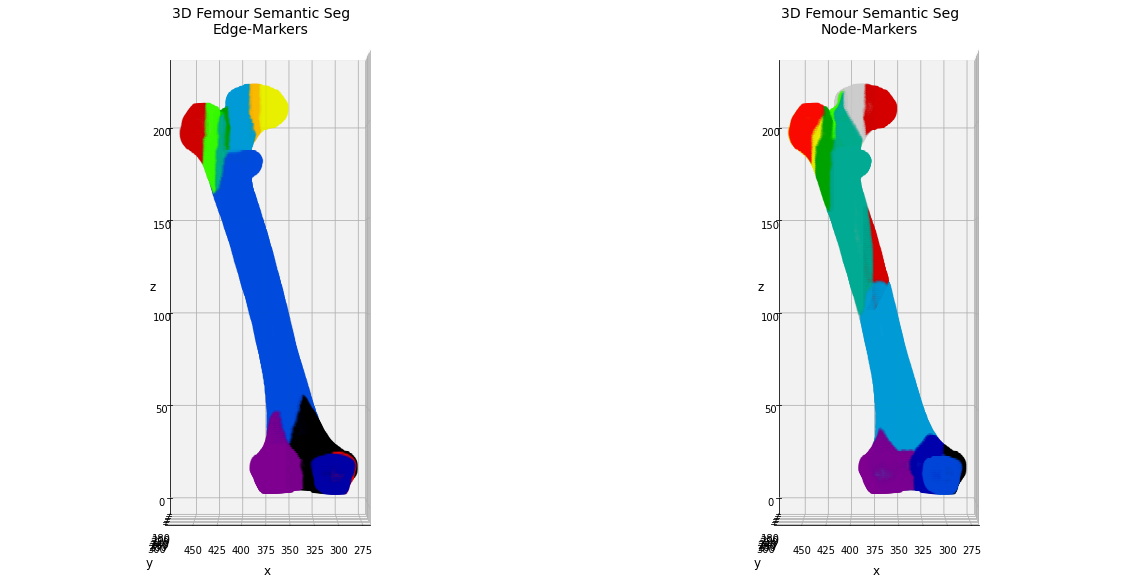

In [121]:
# plot the results in a 3D graph
fig = plt.figure(figsize=(20, 20))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(semantic_seg_edge_markers, 0)

# draw the object volume
ptz, pty, ptx = verts.T

ax1.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax1.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)*2))
ax1.view_init(elev=0., azim=90)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_zlabel('z', fontsize=12)
_ = ax1.set_title('3D Femour Semantic Seg\nEdge-Markers', fontsize=14)

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(semantic_seg_node_markers, 0)

# draw the object volume
ptz, pty, ptx = verts.T

ax2.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax2.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)*2))
ax2.view_init(elev=0., azim=90)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_zlabel('z', fontsize=12)
_ = ax2.set_title('3D Femour Semantic Seg\nNode-Markers', fontsize=14)

**TODO**: add discussion of the results

#### Brain parcellation

For this demo we will use a data sample related to a 3D segmentation of a brain MRI scan obtained by the freeSurfer software: the MRI scan belongs to the OASIS dataset (ref. [here](https://www.oasis-brains.org/)) and it is public available on the online [cite](https://www.oasis-brains.org/#data).

As in the previous application on the 3D volume, also in this we will start without any prior-knowledge about the anatomy of the brain, aiming to provide hints about it using the information stored in the skeleton graph.

In [148]:
# load the medical image file
from graphomics import LoadImageFileInAnyFormat

# declare the input filename, in this case a Nifti fmt
filename = '../samples/brain_seg.nii'

# load the volume in a sitk.Image
sitk_vol = LoadImageFileInAnyFormat(
    filepath=filename,
    binarize=True
)

# extract the skeleton of the 3D shape

# define the skeletonizer to use in the following examples
skeletonizer = SkeletonizeImageFilter()

# apply the skleletonization algorithm
skeletonizer.Execute(sitk_vol)
# get the resulting image
skeleton = skeletonizer.GetSkeletonImage()

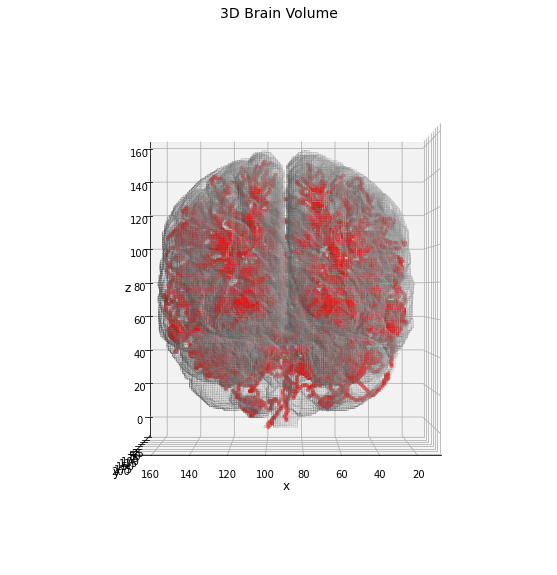

In [149]:
# display 3D mesh
from skimage.measure import marching_cubes

# retro-transform the volume to Numpy fmt for the display
np_vol = sitk.GetArrayViewFromImage(sitk_vol)

# retro-transform the output to Numpy for the display
np_skeleton = sitk.GetArrayFromImage(skeleton)

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(np_vol, 0)

# plot the results in a 3D graph
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.05,
                antialiased=False, 
                linewidth=0.0
               )

# draw the skeleton shape
sz, sy, sx = np.where(np_skeleton)
ax.scatter(sx, sy, sz, color='r', marker='o', s=10, alpha=0.5)

ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.view_init(elev=0., azim=90)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
_ = ax.set_title('3D Brain Volume', fontsize=14)

As expected the resulting skeleton structure is more complex in this case, and a higher number of nodes/edges will be found.
For the identification of the anatomical regions we will use the same pipeline proposed above, comparing the results obtained using the node-markers with edge ones.

In [150]:
# define the graph extractor to use in the following examples
extractor = GraphThicknessImageFilter(# number of dimension of the image
                                      surface_min_points=8,
                                      # minimum number of points for the node identification
                                      remove_surface=False
                                      # remove the skeleton surfaces
                                      )

# execute the filter
extractor.Execute(skeleton)

# get the computed information about the graph
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edgeMap = extractor.GetEdgeMap()

# transform the edgeMap to Numpy fmt
np_edgeMap = sitk.GetArrayFromImage(edgeMap)

In [151]:
# extract the marker mask filtering the mapper and
# selecting only the positive values, i.e. the edge markers
markers = sitk.Threshold(
  image1=edgeMap,
  lower=0,
  upper=len(edges),
  outsideValue=0
)

# apply the watershed algorithm using the marker image
# for the initialization of the seed points
ws = sitk.MorphologicalWatershedFromMarkers(
  image=edgeMap,
  markerImage=markers,
  markWatershedLine=True,
  fullyConnected=False
)

# mask the resulting watershed segmentation according
# to the original mask
ws = sitk.Mask(
  image=ws,
  maskImage=sitk_vol,
  outsideValue=0,
  maskingValue=0,
)
# get the resulting semantic seg as Numpy fmt
semantic_seg_edge_markers = sitk.GetArrayFromImage(ws)

In [152]:
# extract the marker mask filtering the mapper and
# selecting only the negative values, i.e. the node markers
markers = sitk.Threshold(
  image1=edgeMap,
  lower=-len(nodes), # note the flip
  upper=0,
  outsideValue=0
)

# apply the watershed algorithm using the marker image
# for the initialization of the seed points
ws = sitk.MorphologicalWatershedFromMarkers(
  image=edgeMap,
  markerImage=-markers,  # note the flip
  markWatershedLine=True,
  fullyConnected=False
)

# mask the resulting watershed segmentation according
# to the original mask
ws = sitk.Mask(
  image=ws,
  maskImage=sitk_vol,
  outsideValue=0,
  maskingValue=0,
)
# get the resulting semantic seg as Numpy fmt
semantic_seg_node_markers = sitk.GetArrayFromImage(ws)

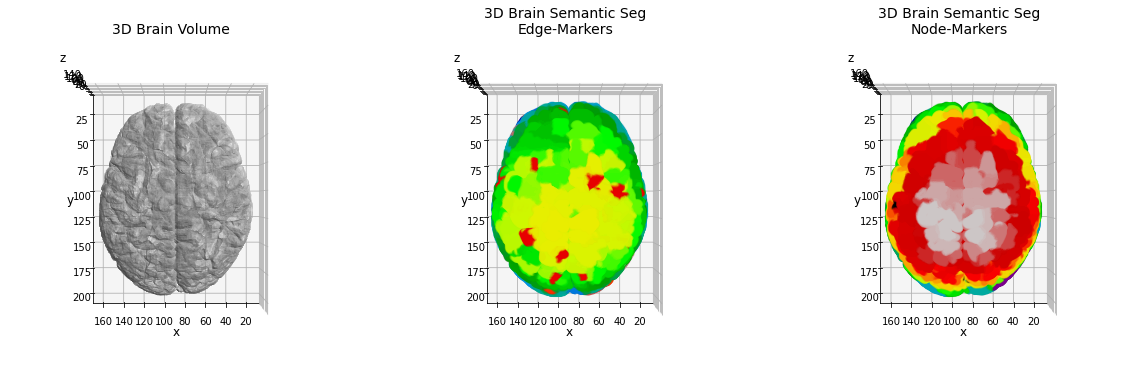

In [153]:
# plot the results in a 3D graph
fig = plt.figure(figsize=(20, 20))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(np_vol, 0)

# draw the object volume
ptz, pty, ptx = verts.T
ax1.plot_trisurf(ptx, pty, faces, ptz, 
                 color='lightgray',
                 alpha=0.05,
                 antialiased=False, 
                 linewidth=0.0
                )
ax1.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax1.view_init(elev=90., azim=90)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_zlabel('z', fontsize=12)
_ = ax1.set_title('3D Brain Volume', fontsize=14)

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(semantic_seg_edge_markers, 0)

# draw the object volume
ptz, pty, ptx = verts.T

ax2.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax2.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax2.view_init(elev=90., azim=90)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_zlabel('z', fontsize=12)
_ = ax2.set_title('3D Brain Semantic Seg\nEdge-Markers', fontsize=14)

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(semantic_seg_node_markers, 0)

# draw the object volume
ptz, pty, ptx = verts.T

ax3.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax3.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax3.view_init(elev=90., azim=90)
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_zlabel('z', fontsize=12)
_ = ax3.set_title('3D Brain Semantic Seg\nNode-Markers', fontsize=14)

The huge quantity of nodes and edges, in this case tends to alter the split of the brain anatomy in a reasonable number of classes.
The high number of ramifications found, indeed, produce an intricated network graph which hasn't got a direct relation to the standard parcellation.

An alternative way to simplify the amount of classes is given by the application of some pre-processing on the skeleton-network structure.
A possible solution could be given by the application of some clustering algorithms on the graph, splitting the available nodes in a limited series of classes.
In the next application we will apply the *community detection* algorithm on the skeleton graph to achieve this purpose, aiming to preserve a reasonable amount of the information.

In [154]:
from graphomics import GraphFilter
import networkx as nx

# build a networkx graph using the graphomics filter
graph_proxy = GraphFilter()
# execute the filter on the inputs
graph_proxy.Execute(
  nodelist=nodes,
  edgelist=edges,
  weights=None
)
# get the graph and store it in the common inputs
G = graph_proxy.GetGraph()

# apply on it the community detection algorithm
community = list(nx.community.louvain_communities(G, seed=42))
print(f'Found {len(community)} communities in the skeleton graph, over {G.number_of_nodes()} nodes')

Found 25 communities in the skeleton graph, over 1150 nodes


A number of 25 communities is certainly more reasonable than 1150 anatomical areas.
Now we can re-label our brain setting the marker described by the community detection algorithm.
Since each community is identified by the list of nodes (coordinates) which belong to it, we can create an empty volume (with the same shape of the brain one, setting the list of markers manually.

In [155]:
# marker mask
marker = np.zeros_like(np_vol)

# loop along the communities list
# NOTE: the index of the list identifies the community label
for m, nodelist in enumerate(community):
    # for each node coordinate
    for n in nodelist:
        # set the marker as label + 1, since the 0 is
        # reserved to the background marker
        # NOTE: you need to correct the order of the coordinates
        marker[n[::-1]] = m + 1
        
# transform the marker volume into a sitk.Image
sitk_marker = sitk.GetImageFromArray(marker)
# copy the metadata information
sitk_marker.CopyInformation(sitk_vol)

# apply the watershed algorithm using the marker image
# for the initialization of the seed points
ws = sitk.MorphologicalWatershedFromMarkers(
  image=edgeMap,
  markerImage=sitk_marker,
  markWatershedLine=True,
  fullyConnected=False
)

# mask the resulting watershed segmentation according
# to the original mask
ws = sitk.Mask(
  image=ws,
  maskImage=sitk_vol,
  outsideValue=0,
  maskingValue=0,
)
# get the resulting semantic seg as Numpy fmt
semantic_seg_community_markers = sitk.GetArrayFromImage(ws)

Text(0.5, 0, 'z')

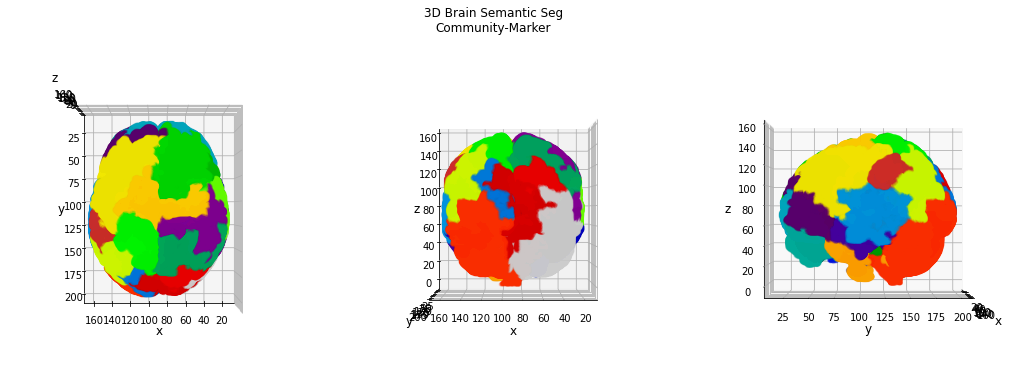

In [171]:
# plot the results in a 3D graph
fig = plt.figure(figsize=(18, 6))
fig.suptitle('3D Brain Semantic Seg\nCommunity-Marker')
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(semantic_seg_community_markers, 0)

# draw the object volume
ptz, pty, ptx = verts.T

ax1.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax1.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax1.view_init(elev=90., azim=90)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_zlabel('z', fontsize=12)

ax2.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax2.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax2.view_init(elev=0., azim=90)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_zlabel('z', fontsize=12)

ax3.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax3.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax3.view_init(elev=0., azim=0)
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_zlabel('z', fontsize=12)

fig.tight_layout()

This result appears more consistent with a brain parcellation, and we can clearly identify some interesting areas on the brain surface.

**TODO**: add discussion of the results

#### Liver anatomy

For this demo we will use a data sample related to a 3D segmentation of a liver acquired by CT: the CT scan belongs to the Lits dataset (ref. [here](https://www.kaggle.com/datasets/andrewmvd/lits-png)) and it is public available on the online [cite](https://www.kaggle.com/datasets/andrewmvd/liver-tumor-segmentation).

Also in this case we will try to determine anatomical information about the liver organ, starting from the semantic segmentation obtained by skeleton-graph analysis.
Since it is the third application example, in the next we will skip some boring comments, leaving the code to do our job.

In [172]:
# load the medical image file
from graphomics import LoadImageFileInAnyFormat

# declare the input filename, in this case a Nifti fmt
filename = '../samples/liver_seg.nii'

# load the volume in a sitk.Image
sitk_vol = LoadImageFileInAnyFormat(
    filepath=filename,
    binarize=True
)

# extract the skeleton of the 3D shape

# define the skeletonizer to use in the following examples
skeletonizer = SkeletonizeImageFilter()

# apply the skleletonization algorithm
skeletonizer.Execute(sitk_vol)
# get the resulting image
skeleton = skeletonizer.GetSkeletonImage()

# define the graph extractor to use in the following examples
extractor = GraphThicknessImageFilter(# number of dimension of the image
                                      surface_min_points=8,
                                      # minimum number of points for the node identification
                                      remove_surface=False
                                      # remove the skeleton surfaces
                                      )

# execute the filter
extractor.Execute(skeleton)

# get the computed information about the graph
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edgeMap = extractor.GetEdgeMap()

# transform the edgeMap to Numpy fmt
np_edgeMap = sitk.GetArrayFromImage(edgeMap)

from graphomics import GraphFilter
import networkx as nx

# build a networkx graph using the graphomics filter
graph_proxy = GraphFilter()
# execute the filter on the inputs
graph_proxy.Execute(
  nodelist=nodes,
  edgelist=edges,
  weights=None
)
# get the graph and store it in the common inputs
G = graph_proxy.GetGraph()

# apply on it the community detection algorithm
community = list(nx.community.louvain_communities(G, seed=42))
print(f'Found {len(community)} communities in the skeleton graph, over {G.number_of_nodes()} nodes')

Found 12 communities in the skeleton graph, over 149 nodes


Also in this case, the number of nodes found in the skeleton graph certainly overestimates the anatomical information about the liver organ, therefore the application of a clustering algorithm for the nodes (coordinates) is helpful for its simplification.
The Louvain community detection algorithm identifies a total of 12 "anatomical clusters" which can be used as starting point for the watershed semantic segmentation.

In [175]:
# retro-transform the volume to Numpy fmt for the display
np_vol = sitk.GetArrayViewFromImage(sitk_vol)

# marker mask
marker = np.zeros_like(np_vol)

# loop along the communities list
# NOTE: the index of the list identifies the community label
for m, nodelist in enumerate(community):
    # for each node coordinate
    for n in nodelist:
        # set the marker as label + 1, since the 0 is
        # reserved to the background marker
        # NOTE: you need to correct the order of the coordinates
        marker[n[::-1]] = m + 1
        
# transform the marker volume into a sitk.Image
sitk_marker = sitk.GetImageFromArray(marker)
# copy the metadata information
sitk_marker.CopyInformation(sitk_vol)

# apply the watershed algorithm using the marker image
# for the initialization of the seed points
ws = sitk.MorphologicalWatershedFromMarkers(
  image=edgeMap,
  markerImage=sitk_marker,
  markWatershedLine=True,
  fullyConnected=False
)

# mask the resulting watershed segmentation according
# to the original mask
ws = sitk.Mask(
  image=ws,
  maskImage=sitk_vol,
  outsideValue=0,
  maskingValue=0,
)
# get the resulting semantic seg as Numpy fmt
semantic_seg_community_markers = sitk.GetArrayFromImage(ws)

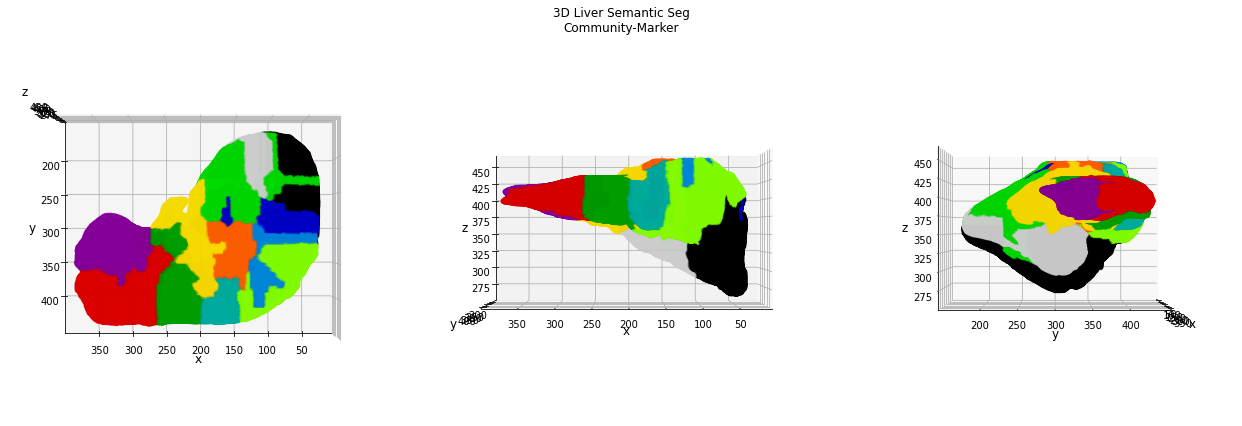

In [179]:
# plot the results in a 3D graph
fig = plt.figure(figsize=(18, 6))
fig.suptitle('3D Liver Semantic Seg\nCommunity-Marker')
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(semantic_seg_community_markers, 0)

# draw the object volume
ptz, pty, ptx = verts.T

ax1.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax1.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax1.view_init(elev=90., azim=90)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_zlabel('z', fontsize=12)

ax2.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax2.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax2.view_init(elev=0., azim=90)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_zlabel('z', fontsize=12)

ax3.scatter(ptx, pty, ptz, 
            c=values,
            cmap='nipy_spectral',
            marker='o', 
            s=10, 
            alpha=0.15
           )

ax3.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax3.view_init(elev=0., azim=0)
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_zlabel('z', fontsize=12)

fig.tight_layout()

**TODO**: add discussion of the results